# New technique Wise


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from matplotlib.lines import Line2D

def plot_layer_metrics(
    file_path: str,
    project_name: str,
    layers: List[int],
    fisher_options: List[bool],
    module_types: List[str],
    title: str,
    ylabel: str,
    component: str,
    metric: str,
    output_file: str = None,
    smooth: bool = False,
    include_fisher_legend: bool = True,
    use_log_scale: bool = True
):
    # Load data
    df = pd.read_csv(file_path)
    x = df['Step']

    # Define styles
    colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']
    line_styles = {True: '--', False: '-'}  # Fisher: dashed, No Fisher: solid
    if not include_fisher_legend:
        line_styles = {True: '-', False: '-'}

    # Set up figure
    fig, ax = plt.subplots(figsize=(12, 8))
    layer_labels_added = set()

    for i, layer in enumerate(layers):
        for j, module in enumerate(module_types):
            for fisher in fisher_options:
                fisher_str = str(fisher).lower()
                col_name = f"layer_{layer}_{component}_{module}_fisher_{fisher_str}_project_{project_name} - {metric}"

                if col_name not in df.columns:
                    print(f"Warning: Missing column '{col_name}'")
                    continue

                y = df[col_name]
                if smooth:
                    y = y.rolling(window=10, min_periods=1).mean()

                # Label each layer only once
                # Only use label for the non-Fisher (solid) line
                if not fisher and layer not in layer_labels_added:
                    label = f"Layer {layer}"
                    layer_labels_added.add(layer)
                else:
                    label = None
                ax.plot(
                    x, y,
                    label=label,
                    color=colors[i % len(colors)],
                    linestyle=line_styles[fisher],
                    linewidth=2,
                    alpha=0.4 if not fisher else 1.0,
                )

    # Axis labels
    ax.set_title(title)
    ax.set_xlabel('Training Step')
    ax.set_ylabel(ylabel)
    if use_log_scale:
        ax.set_yscale('log')
    ax.grid(True, linestyle='--', linewidth=0.5)

    # Get handles for layer lines
    layer_handles, layer_labels = ax.get_legend_handles_labels()

    # Custom legend for Fisher line styles
    custom_lines = []
    if include_fisher_legend:
        custom_lines = [
            Line2D([0], [0], color='black', linestyle='-', label='No Fisher'),
            Line2D([0], [0], color='black', linestyle='--', label='Fisher')
        ]

    # Final legend: Fisher styles + layers
    ax.legend(
        handles=custom_lines + layer_handles,
        loc='upper left',
        fontsize='small',
        title='Legend'
    )

    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()


# GPT2

## Devign

### Residual Mid

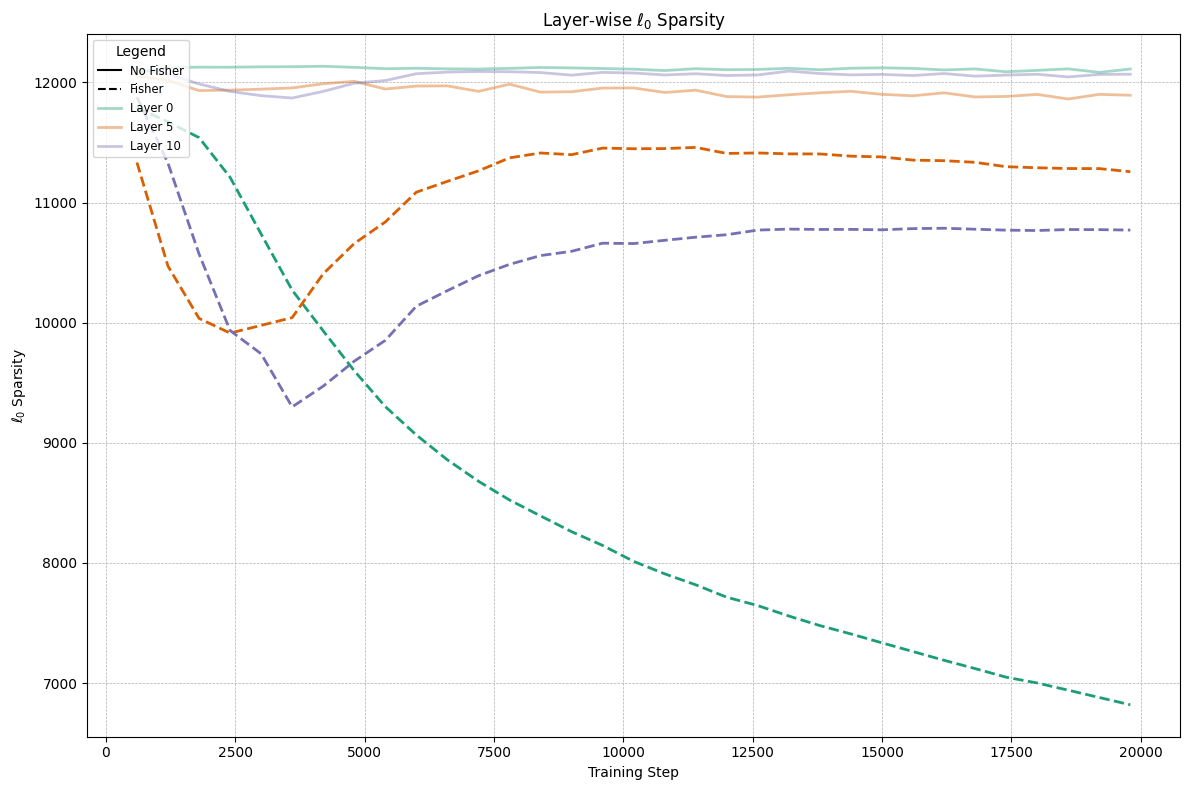

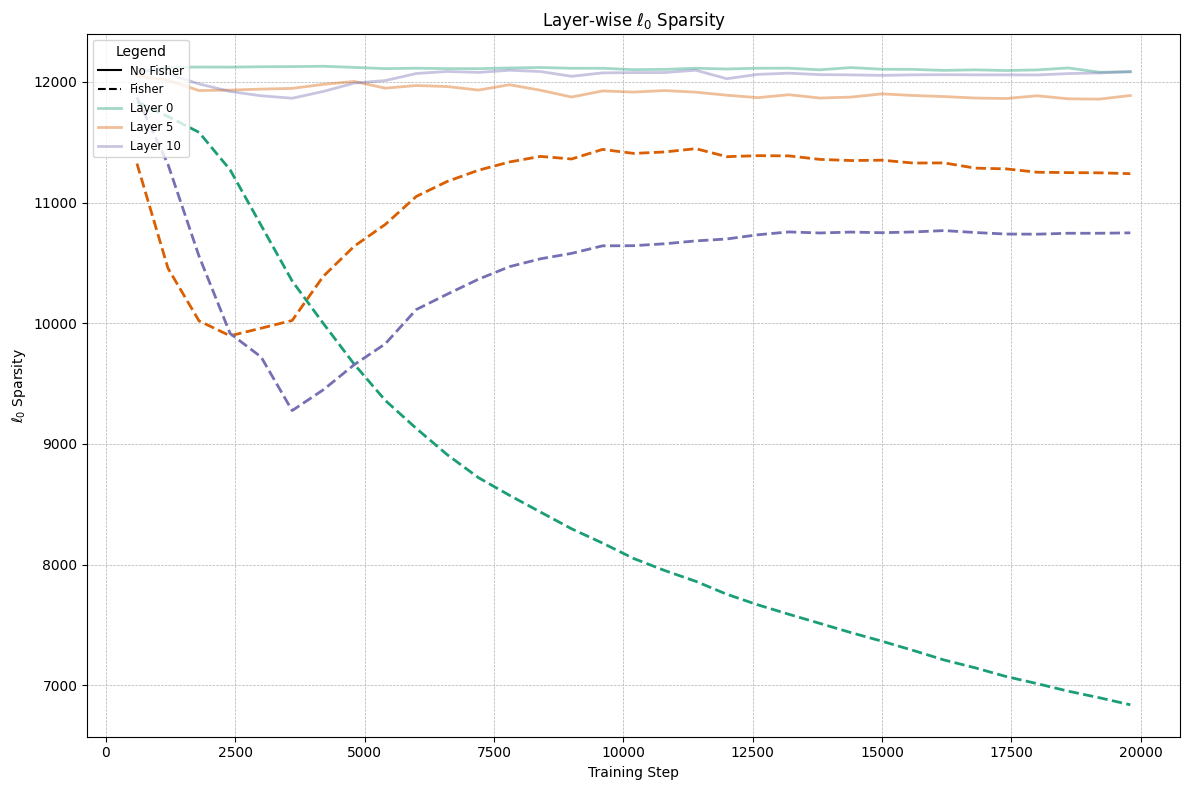

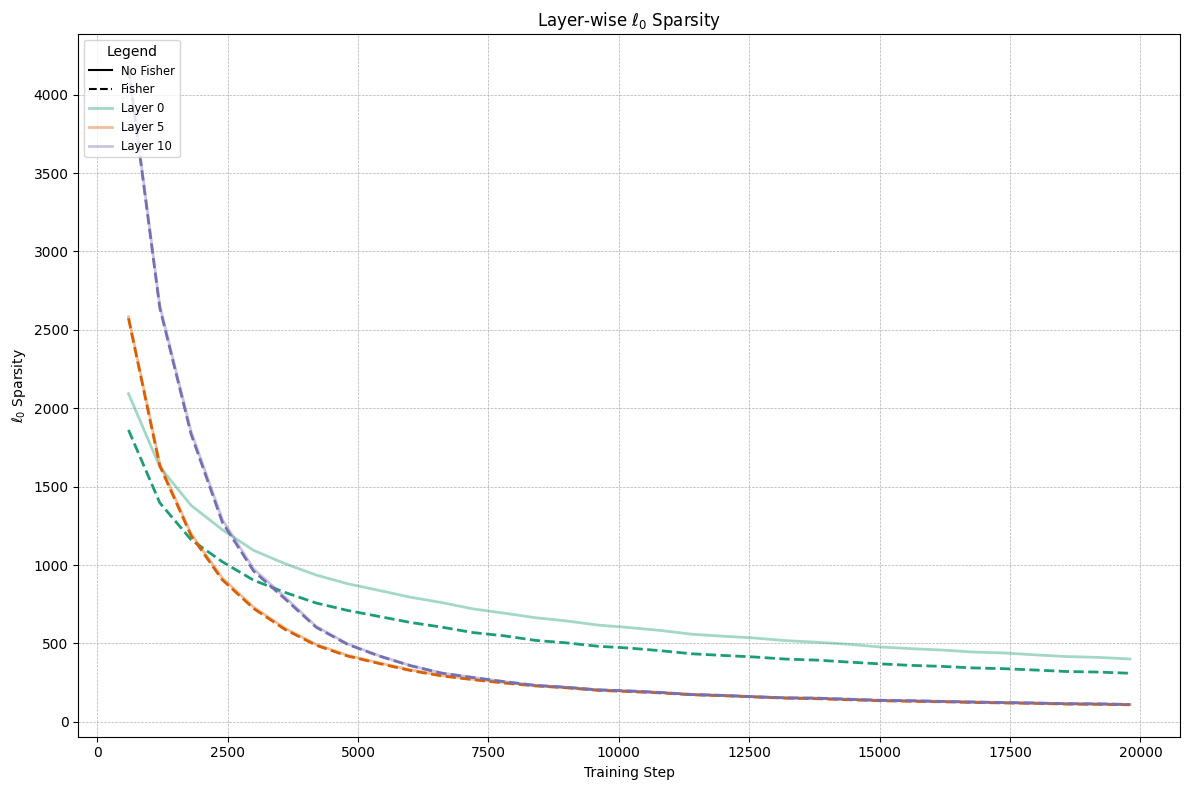

In [2]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_standard_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/standard_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_jumprelu_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/jumprelu_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_gated_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/gated_l0_sparsity_plot.pdf',
    use_log_scale=False
)

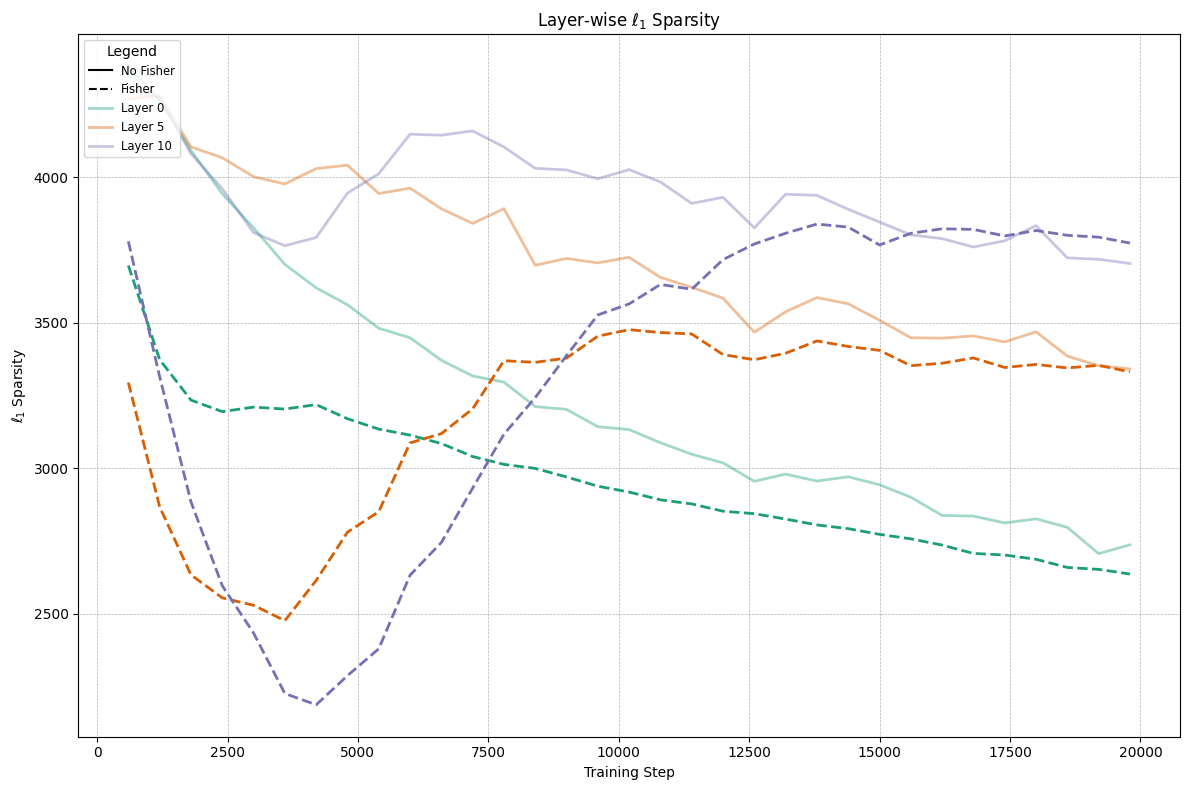

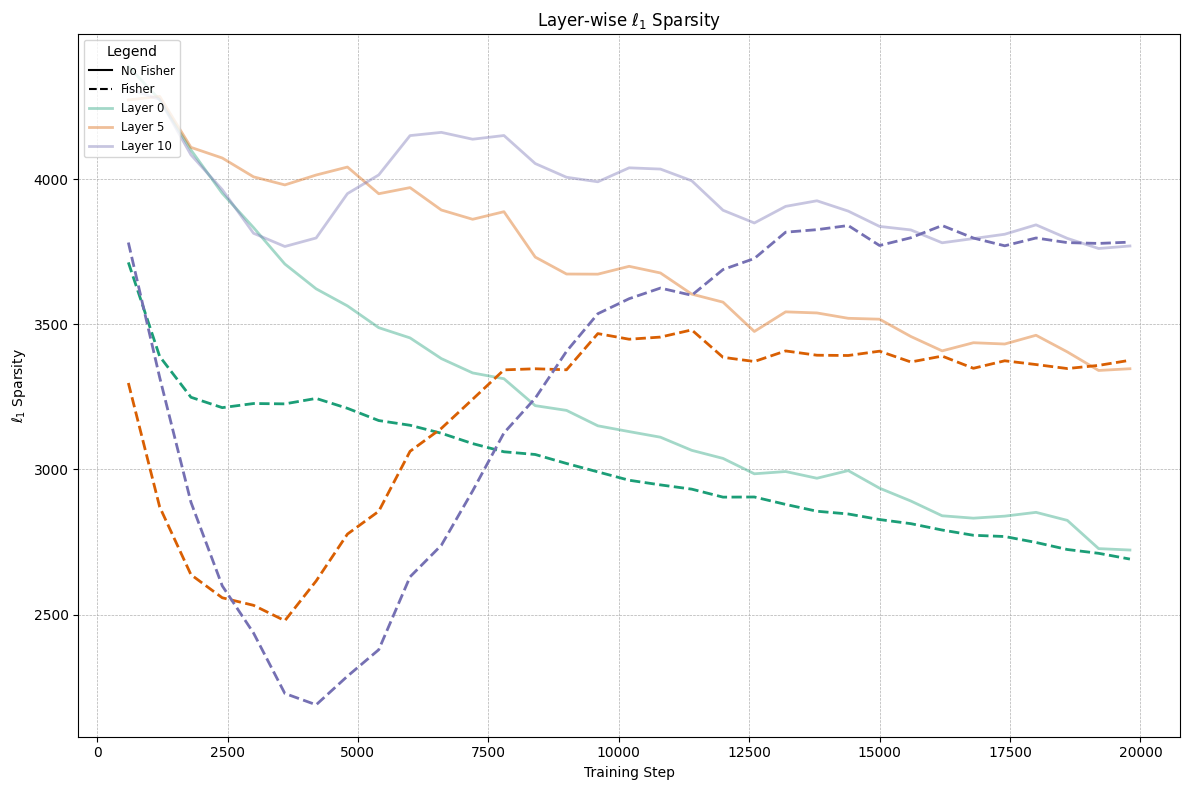

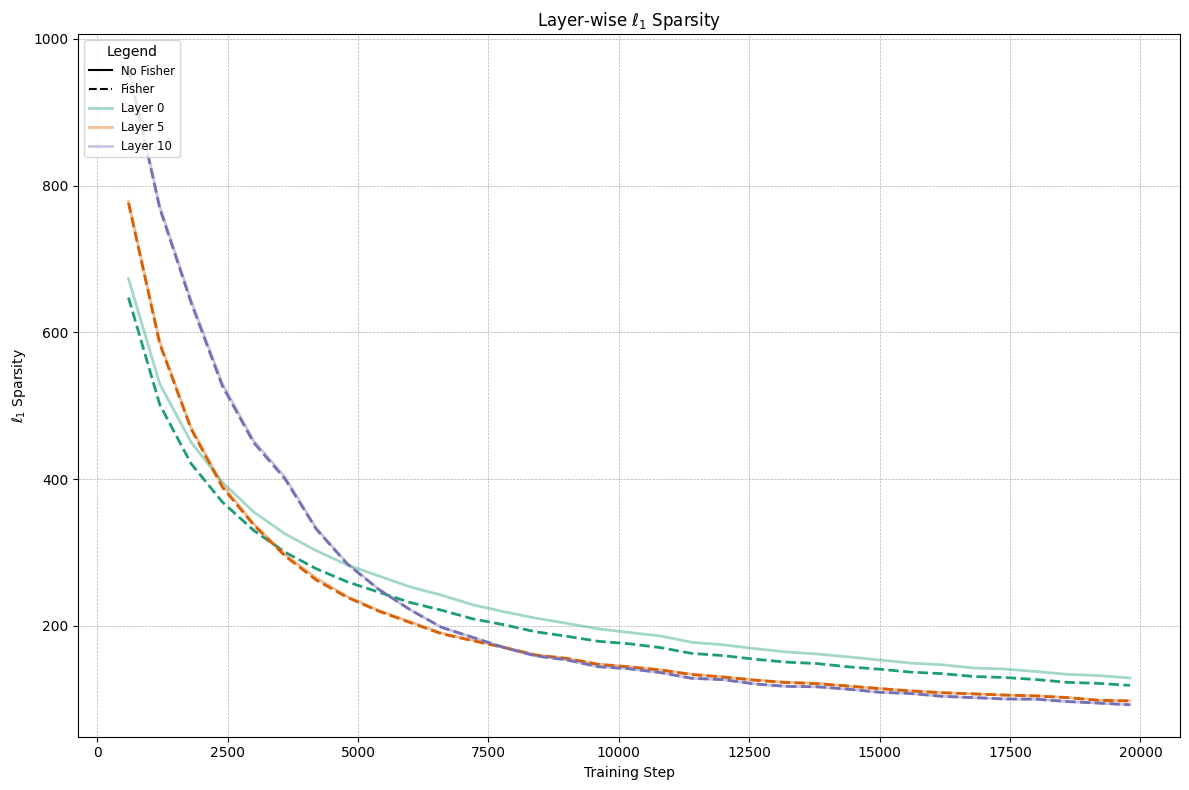

In [3]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_standard_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/standard_l1_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_jumprelu_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/jumprelu_l1_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_gated_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/gated_l1_sparsity_plot.pdf',
    use_log_scale=False
)

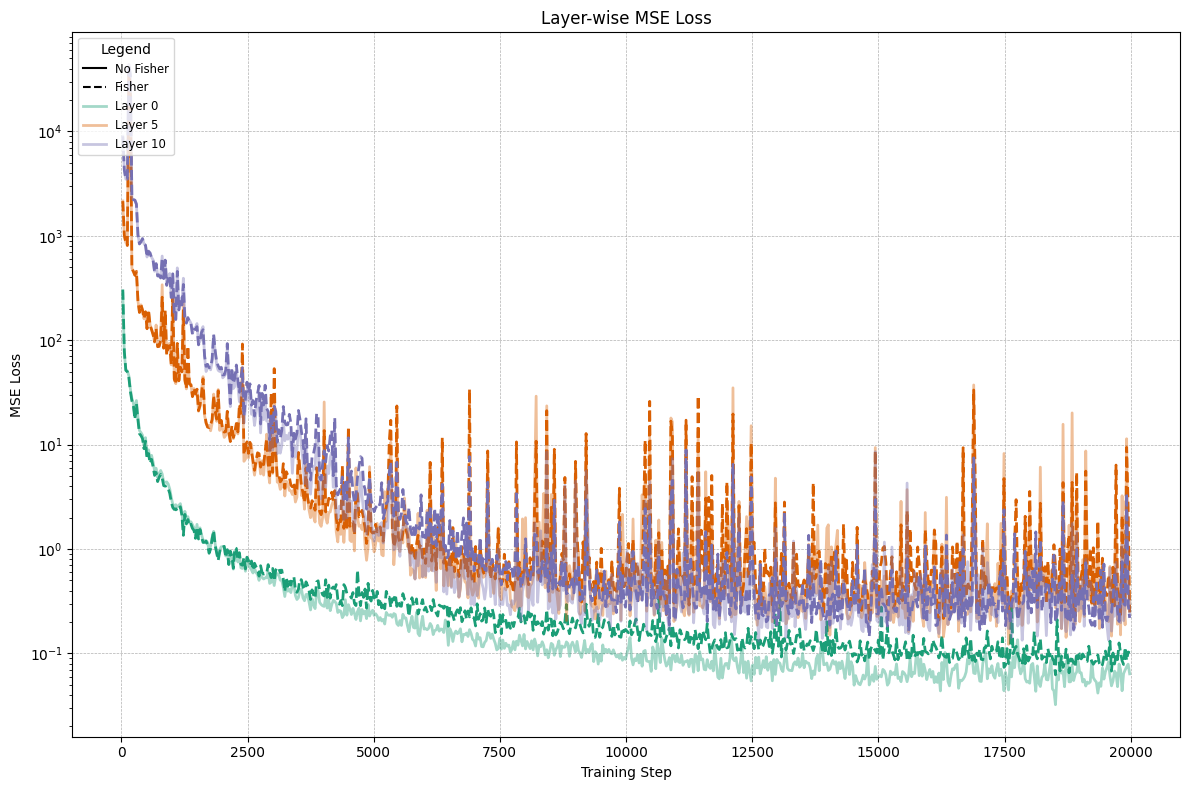

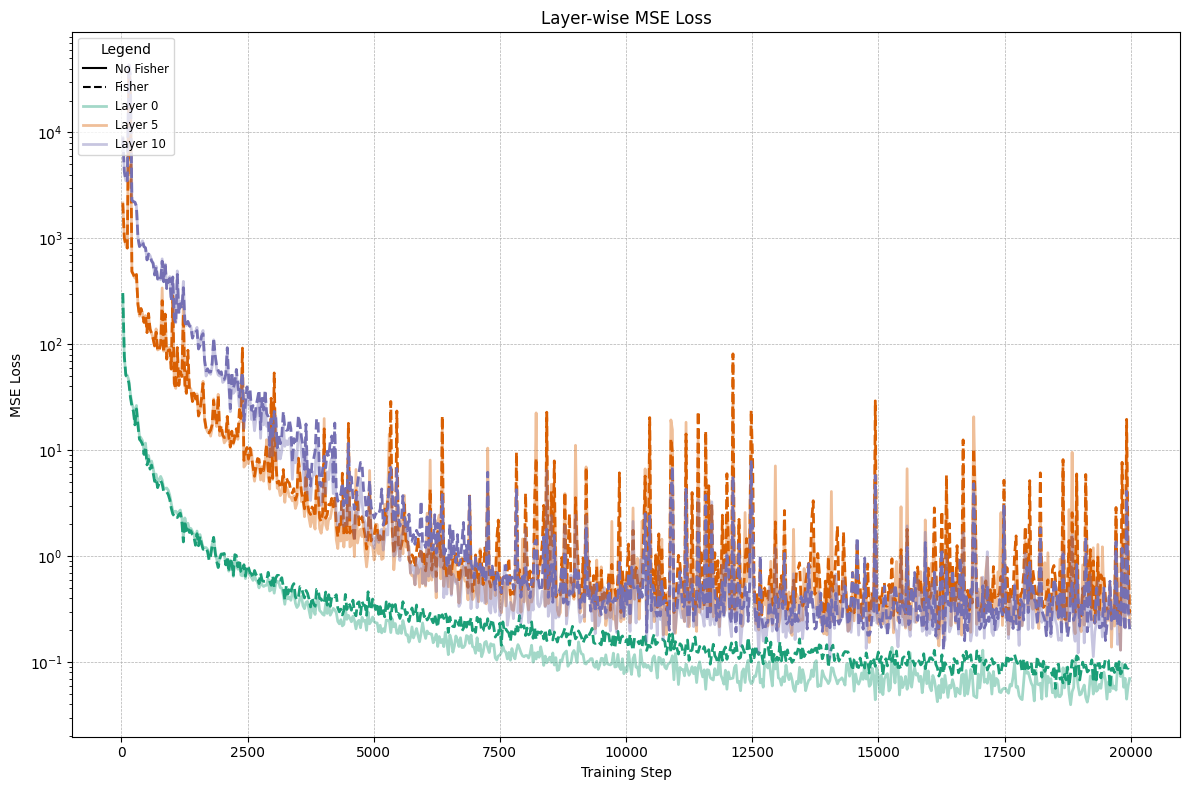

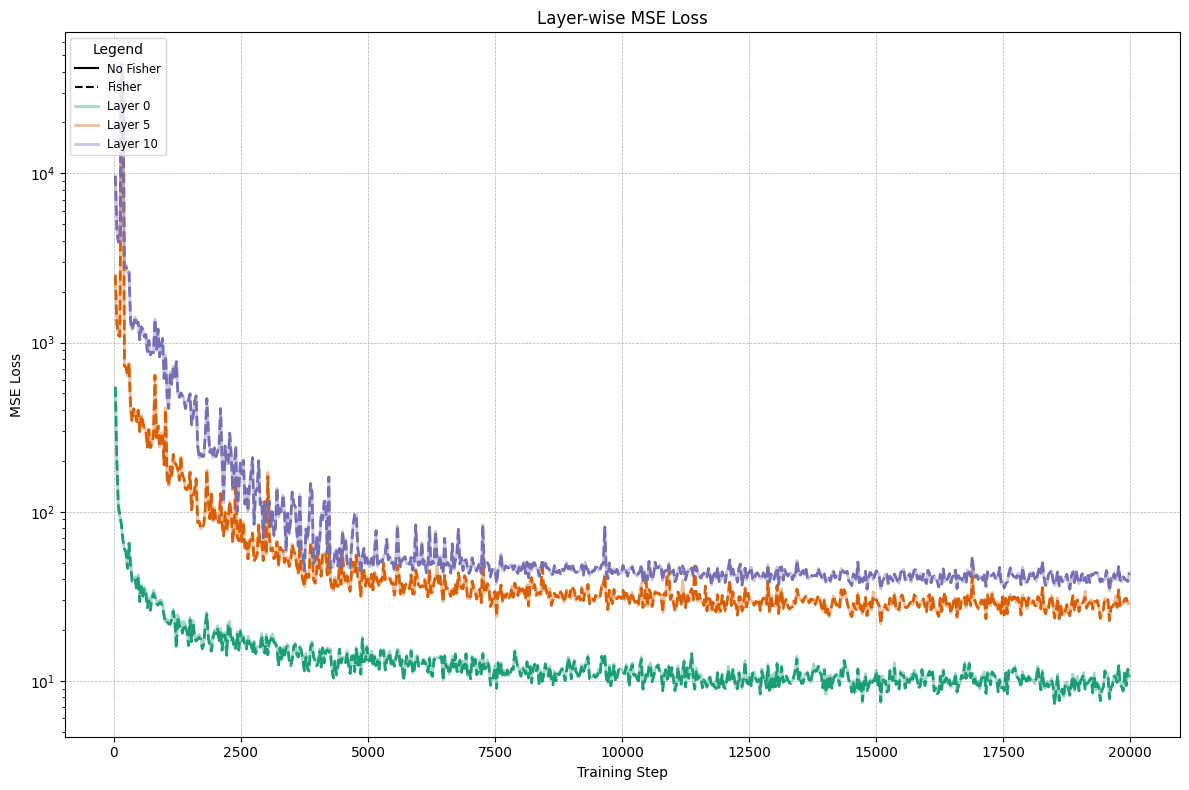

In [4]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_standard_mse_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/standard_mse_loss_plot.pdf',
    use_log_scale=True,
)

plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_jumprelu_mse_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/jumprelu_mse_loss_plot.pdf',
    use_log_scale=True,
)

plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_gated_mse_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/gated_mse_loss_plot.pdf',
    use_log_scale=True,
)

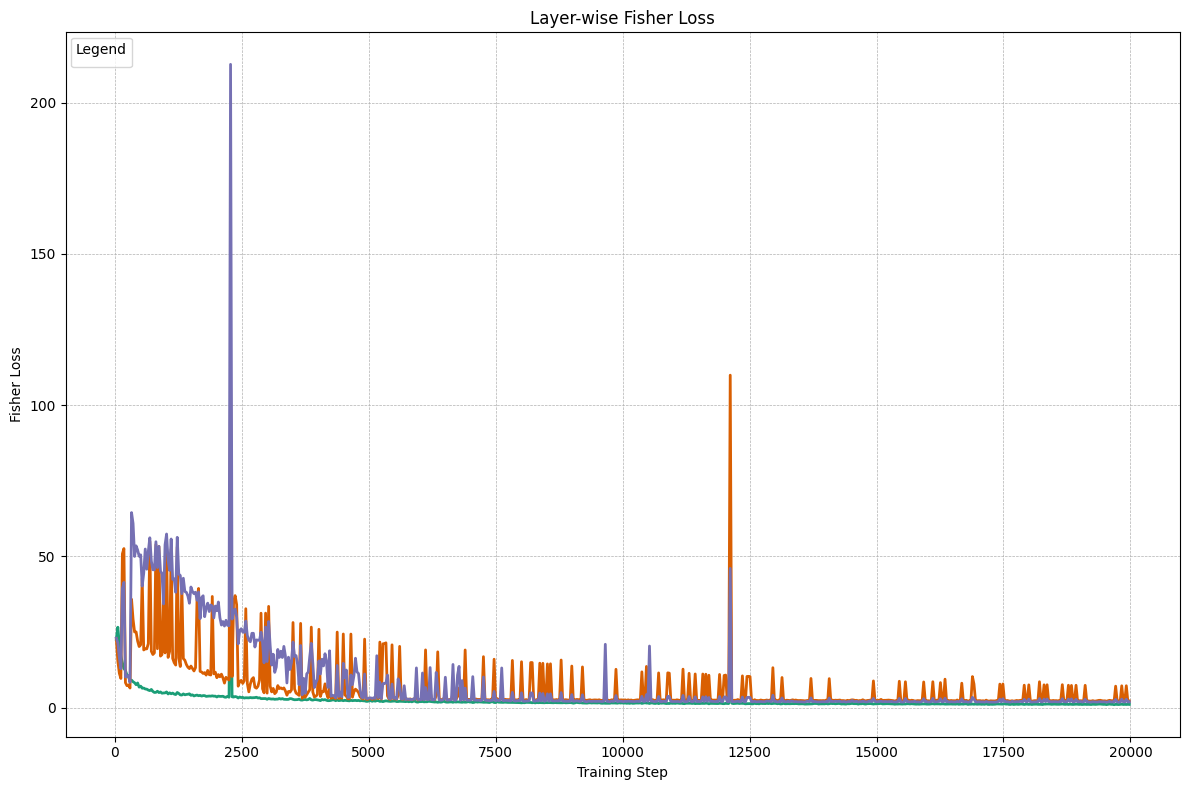

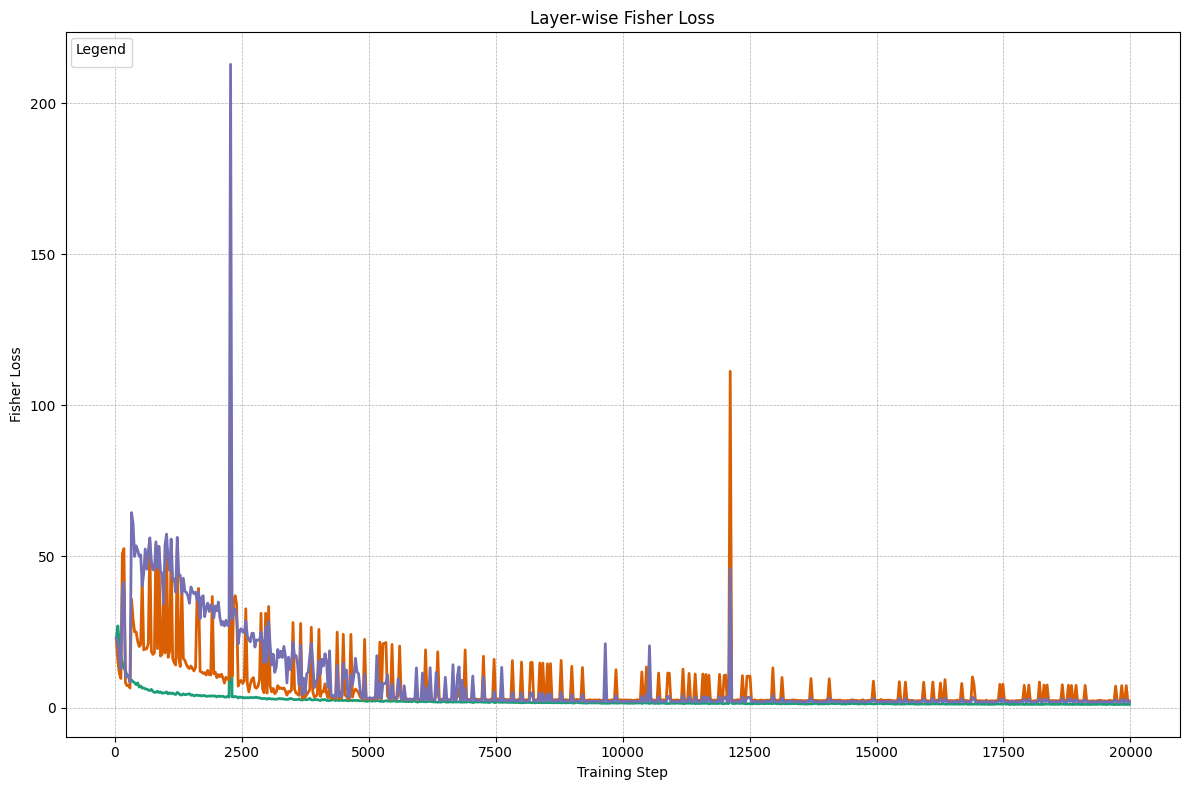

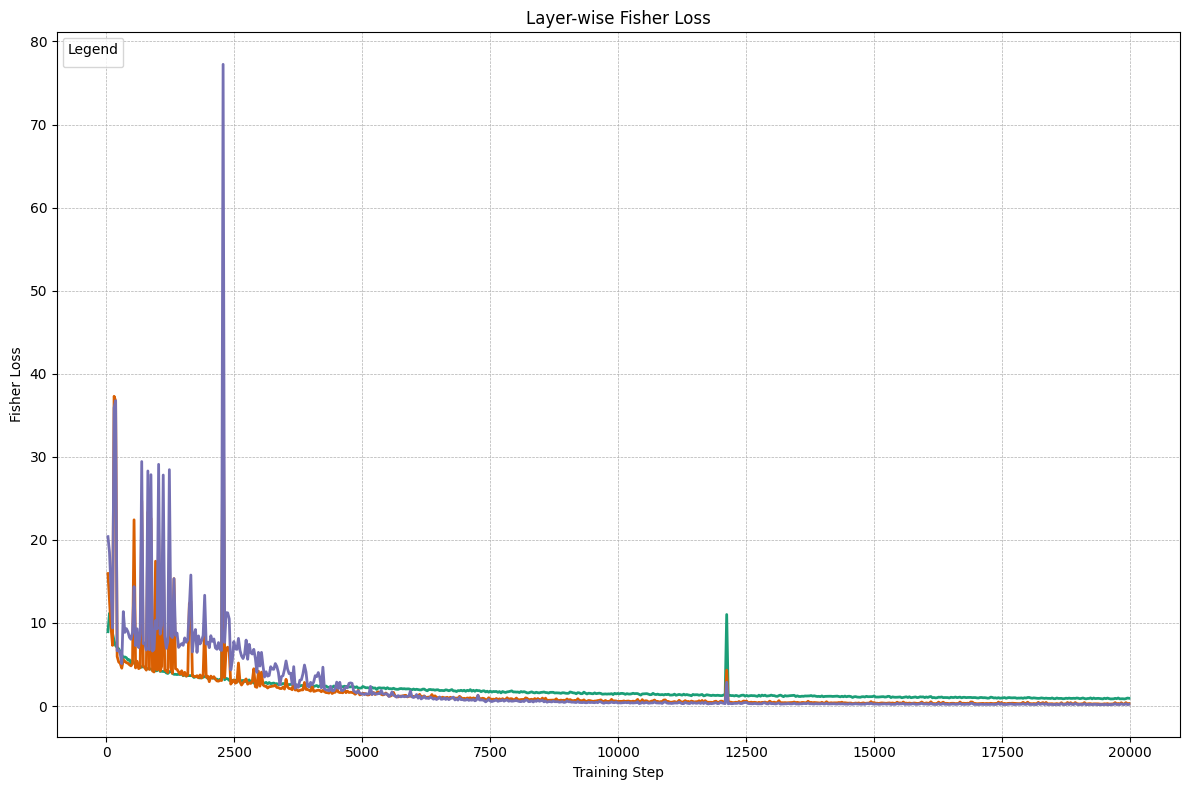

In [5]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_standard_fisher_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer10_fisher_loss_plot.pdf',

    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_jumprelu_fisher_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/jumprelu_fisher_loss_plot.pdf',

    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_gated_fisher_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/gated_fisher_loss_plot.pdf',

    include_fisher_legend=False,
    use_log_scale=False,
)

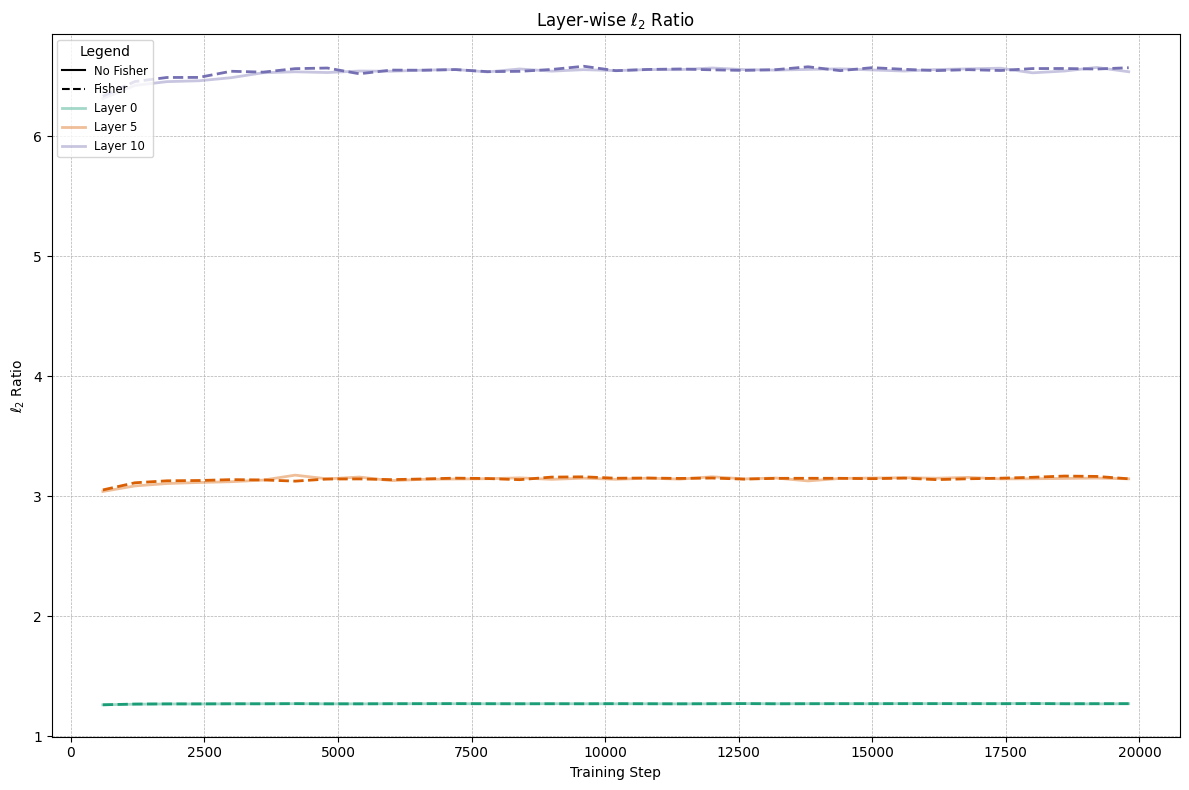

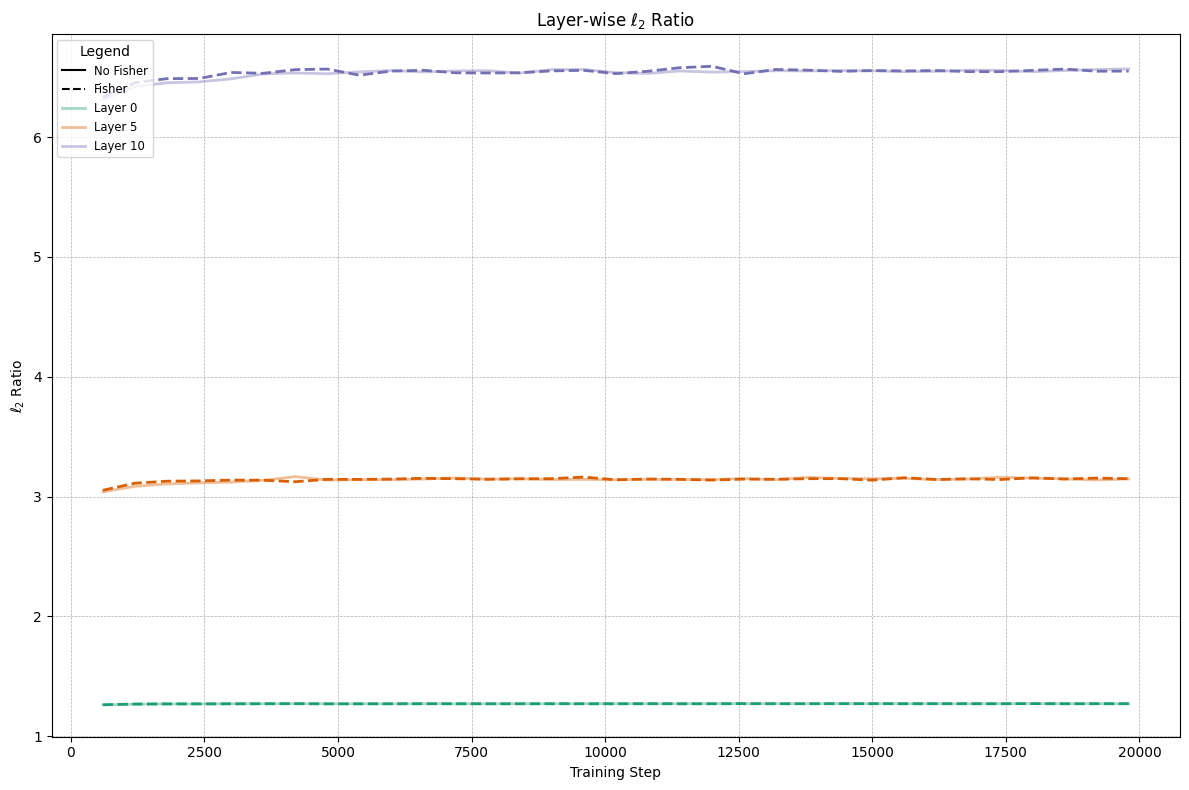

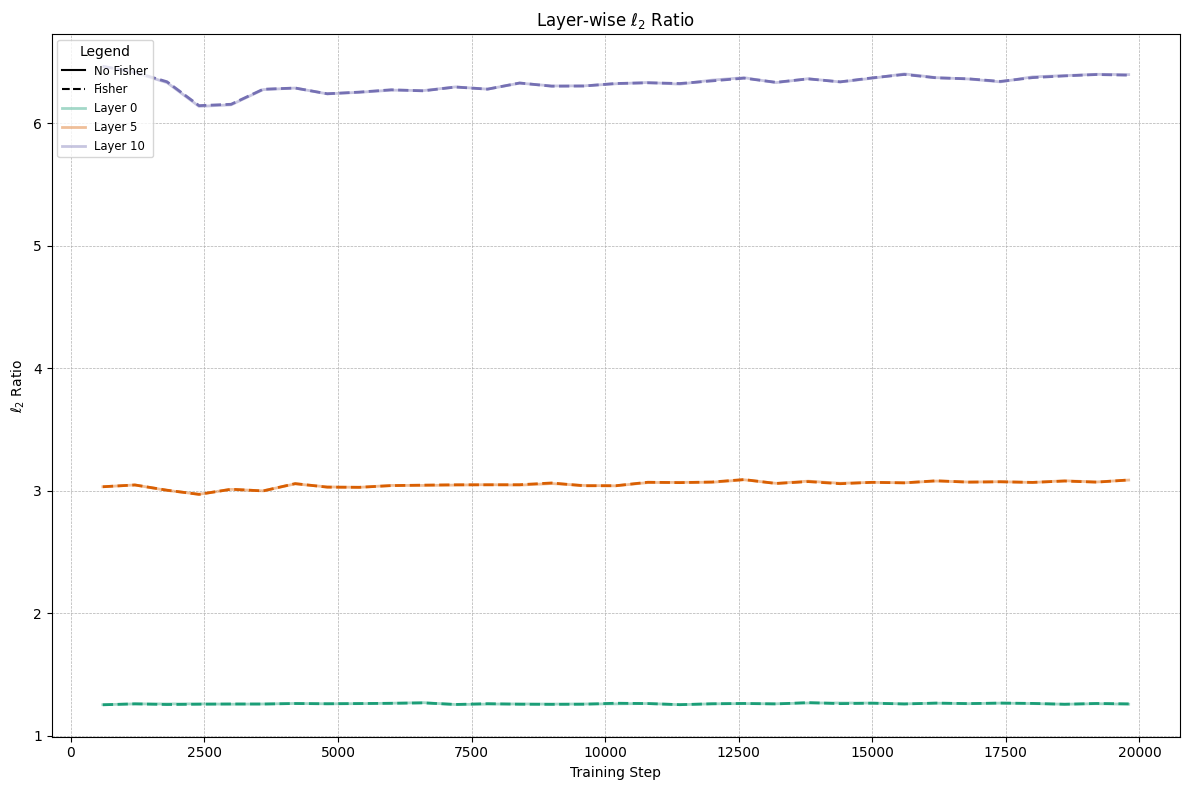

In [6]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_standard_l2_ratio.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/standard_l2_ratio_plot.pdf',
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_jumprelu_l2_ratio.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/jumprelu_l2_ratio_plot.pdf',
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_gated_l2_ratio.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/gated_l2_ratio_plot.pdf',
    use_log_scale=False,
)

### MLP Out

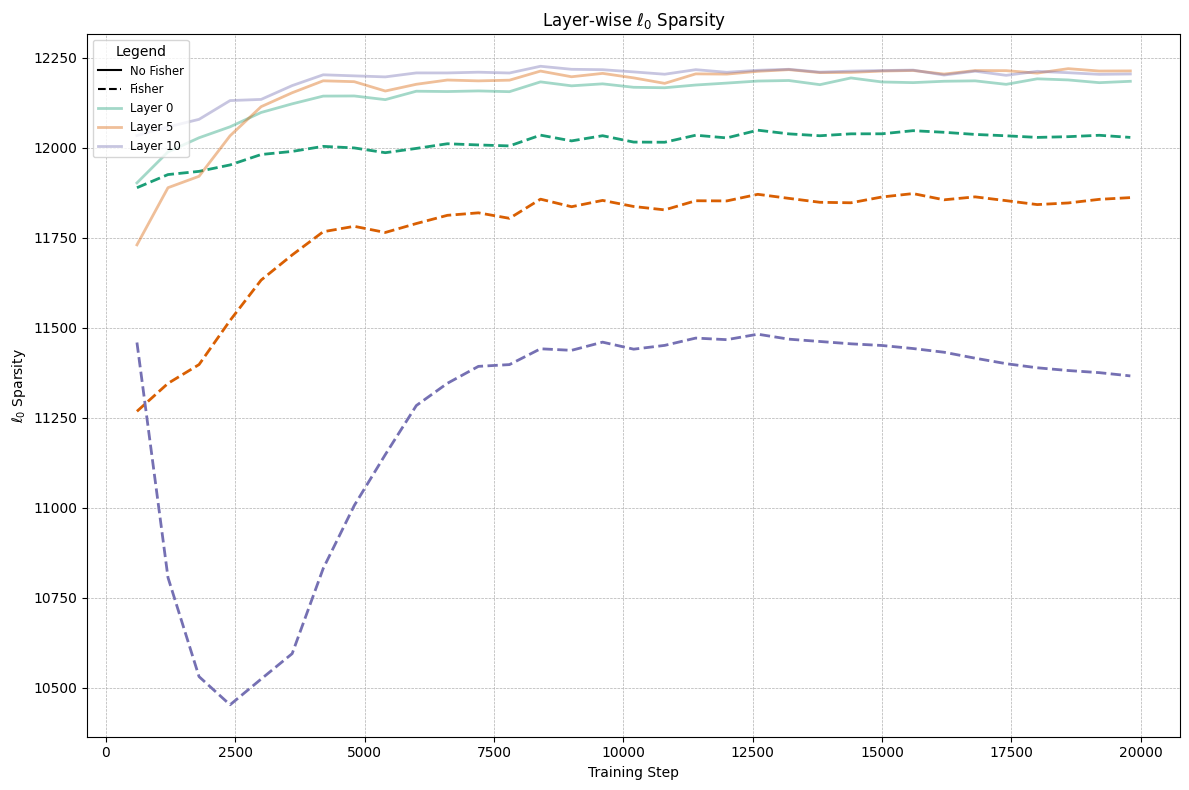

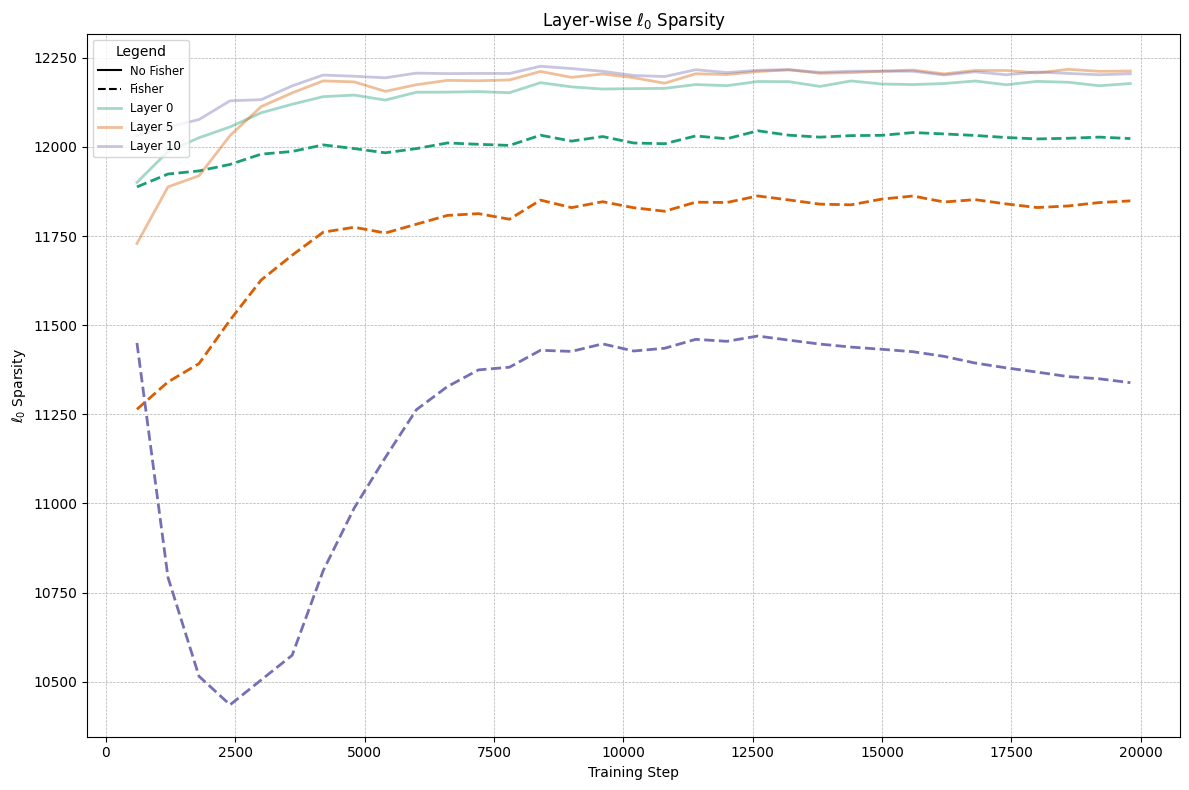

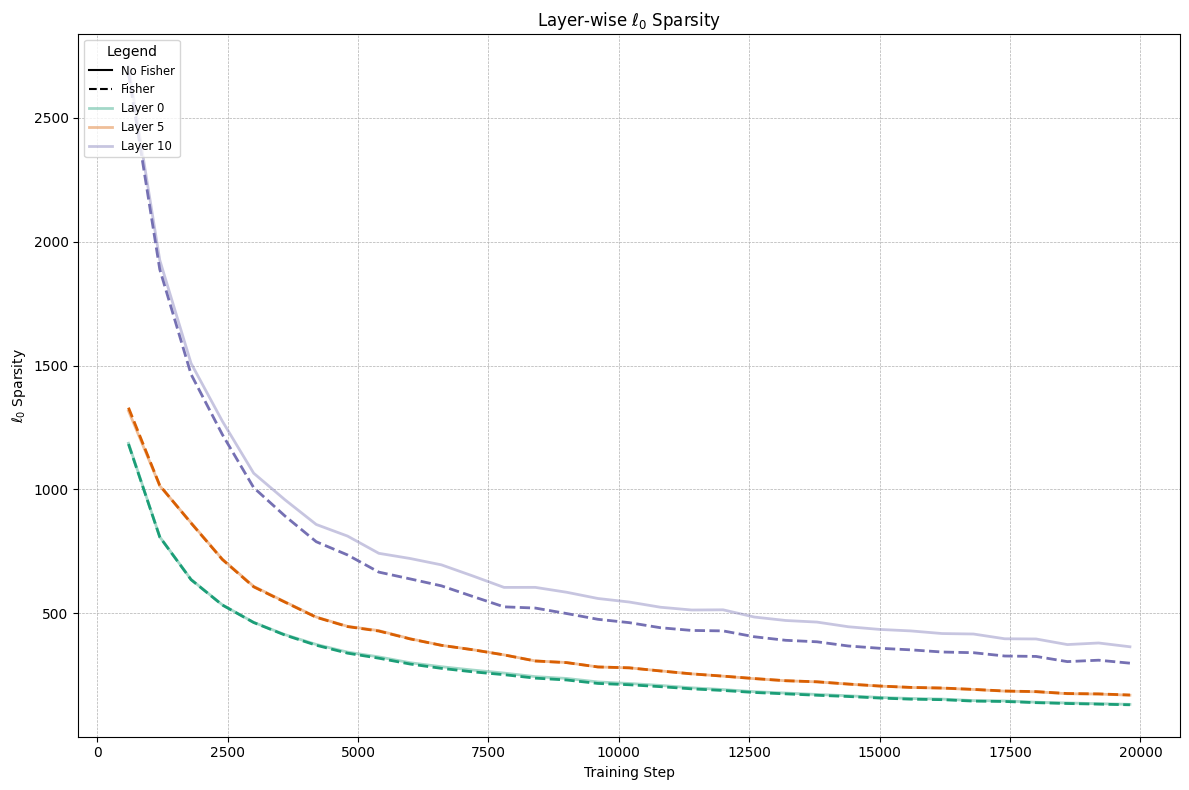

In [7]:
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_standard_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/standard_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_jumprelu_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/jumprelu_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_gated_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/gated_l0_sparsity_plot.pdf',
    use_log_scale=False
)



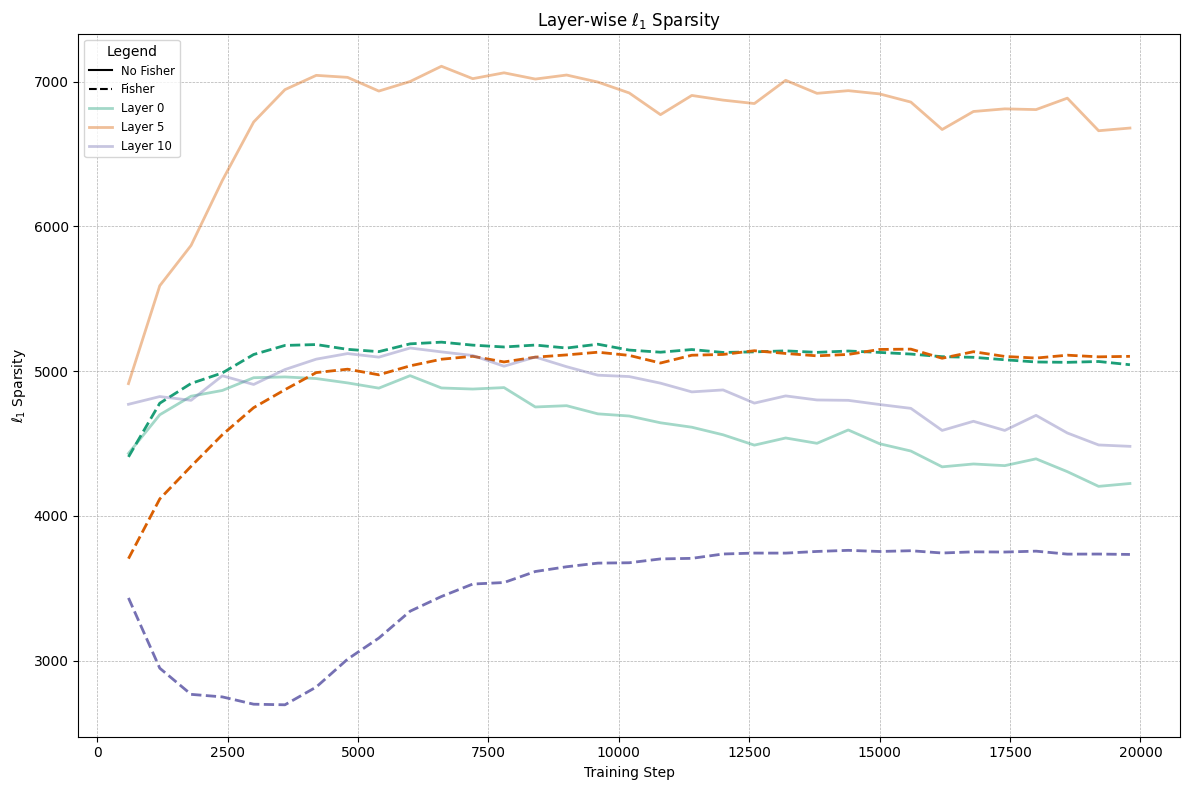

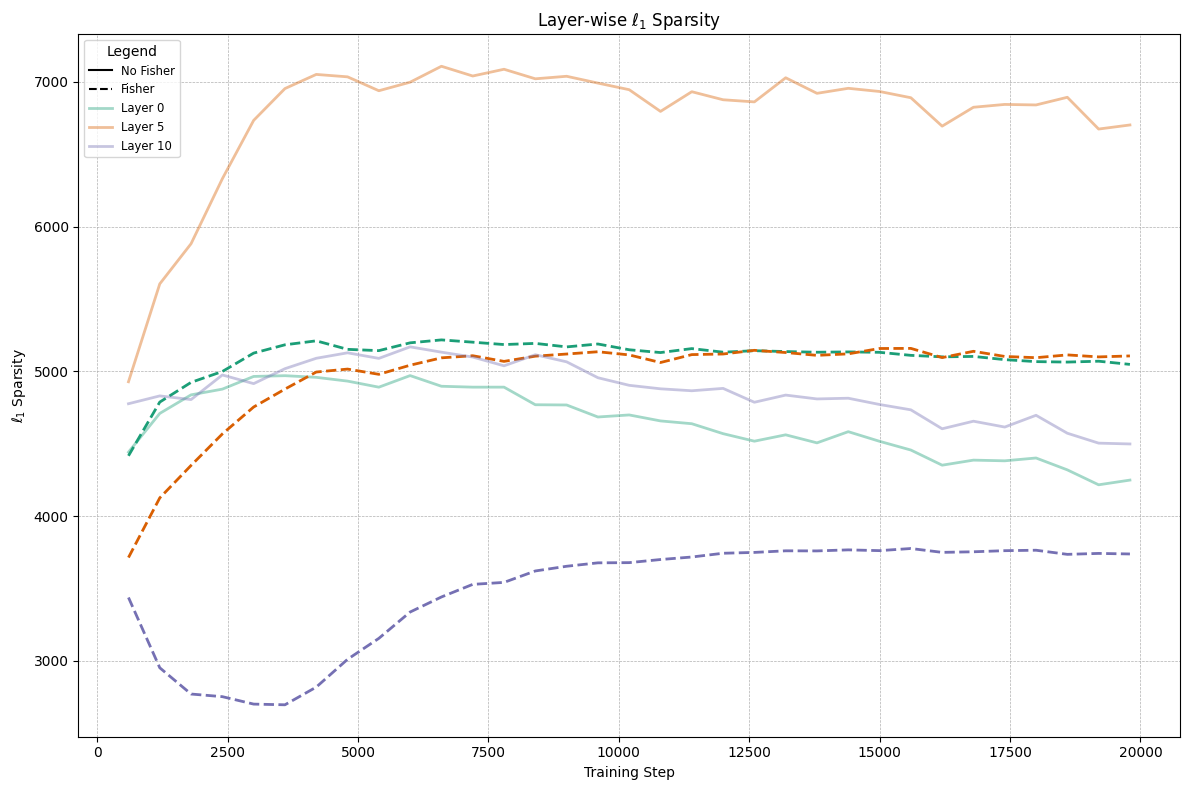

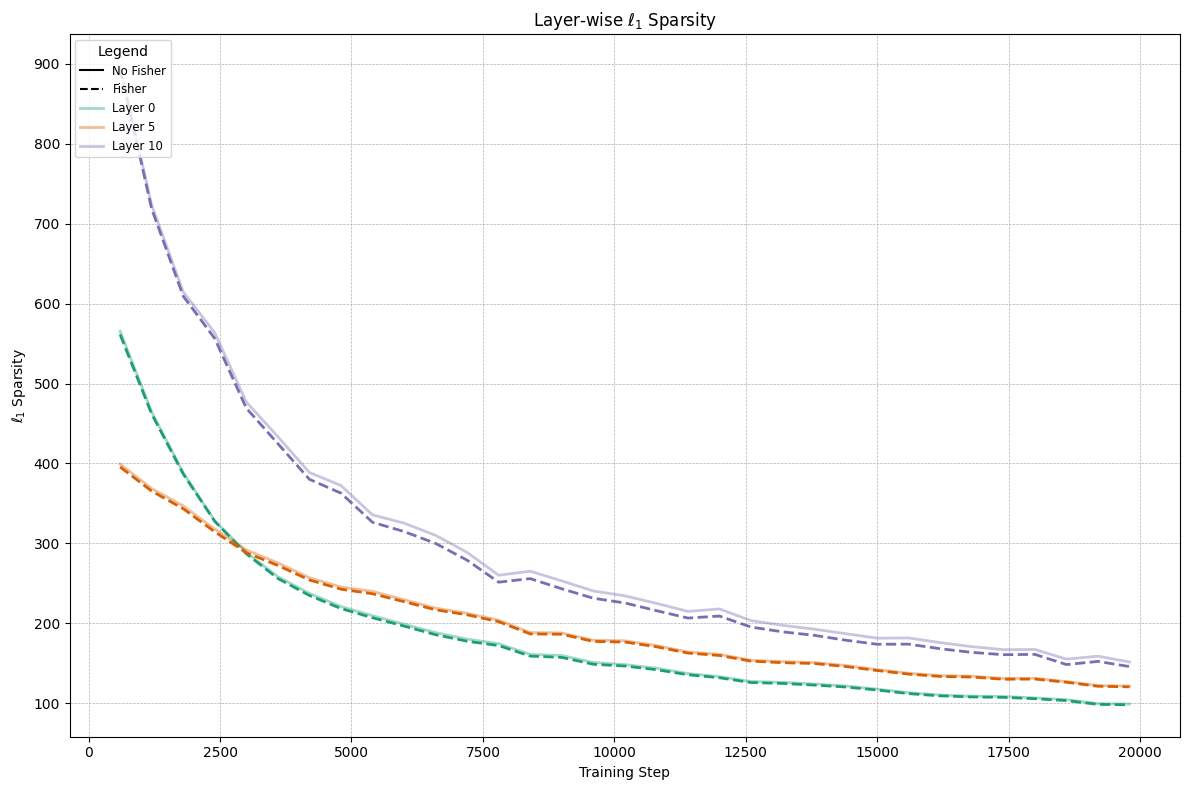

In [8]:
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_standard_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/standard_l1_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_jumprelu_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/jumprelu_l1_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_gated_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/gated_l1_sparsity_plot.pdf',
    use_log_scale=False
)

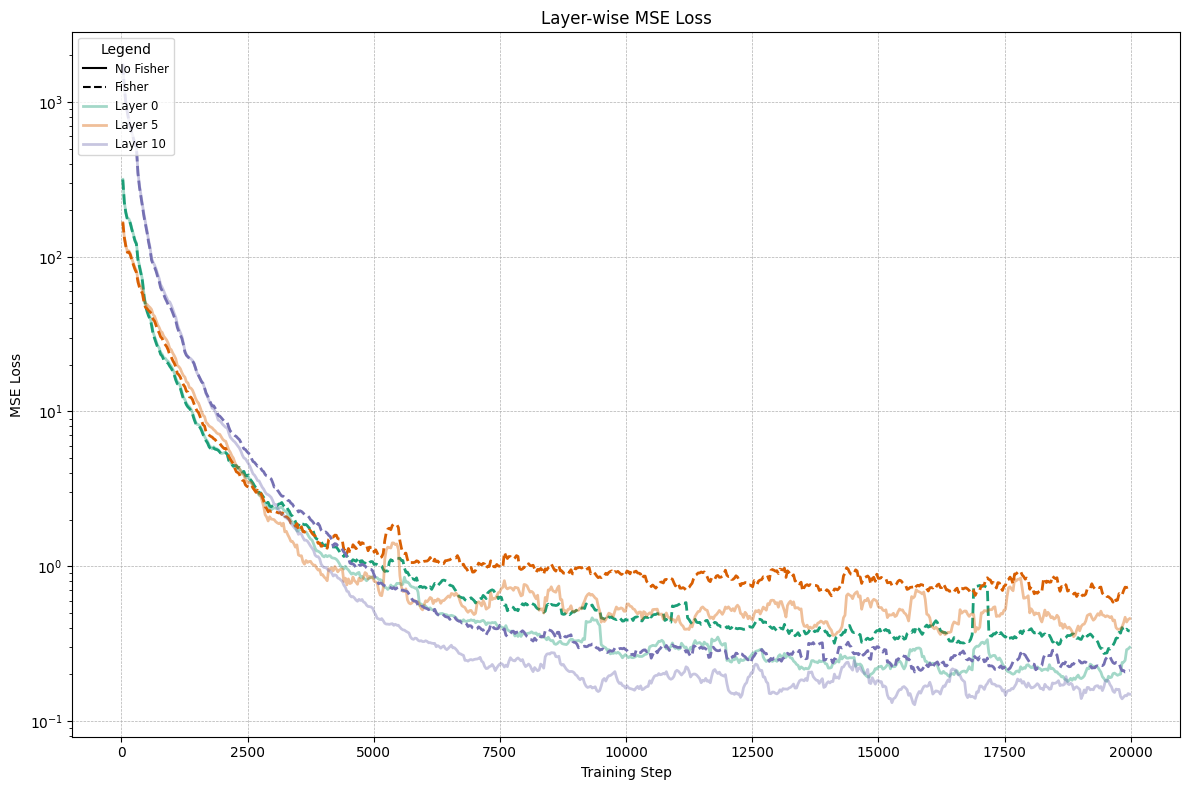

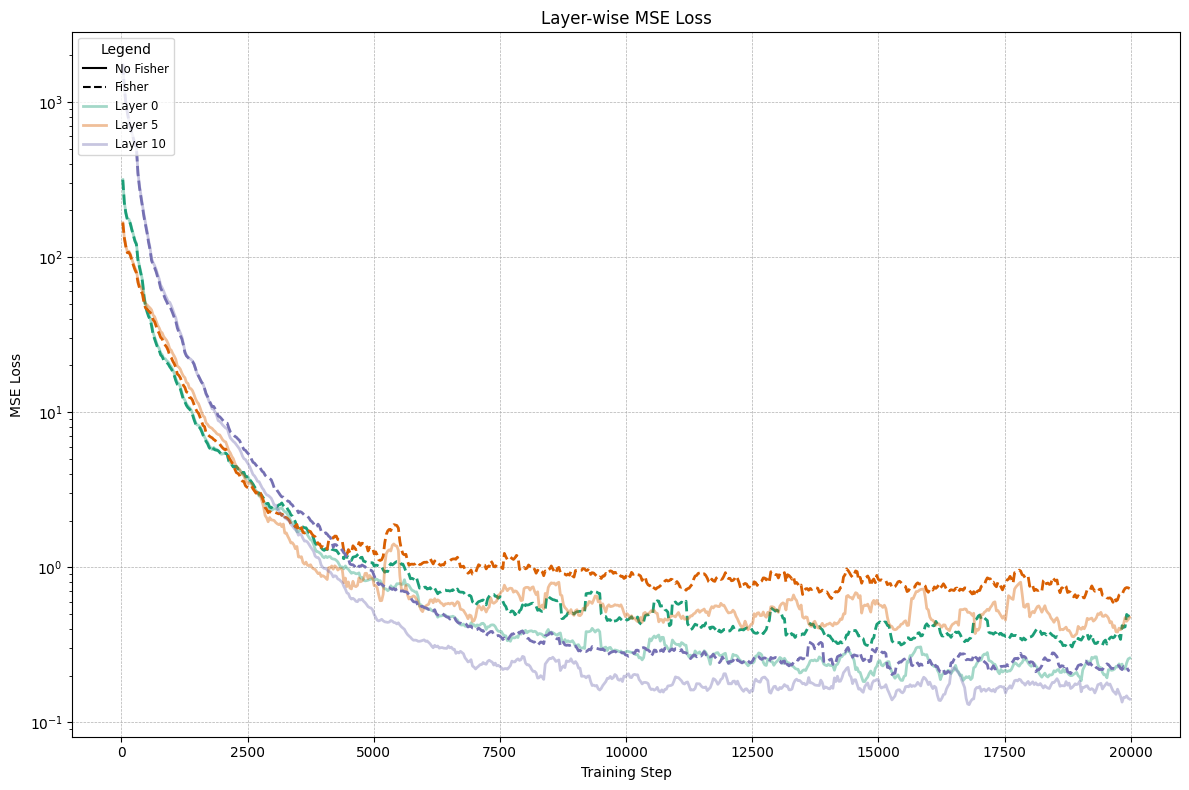

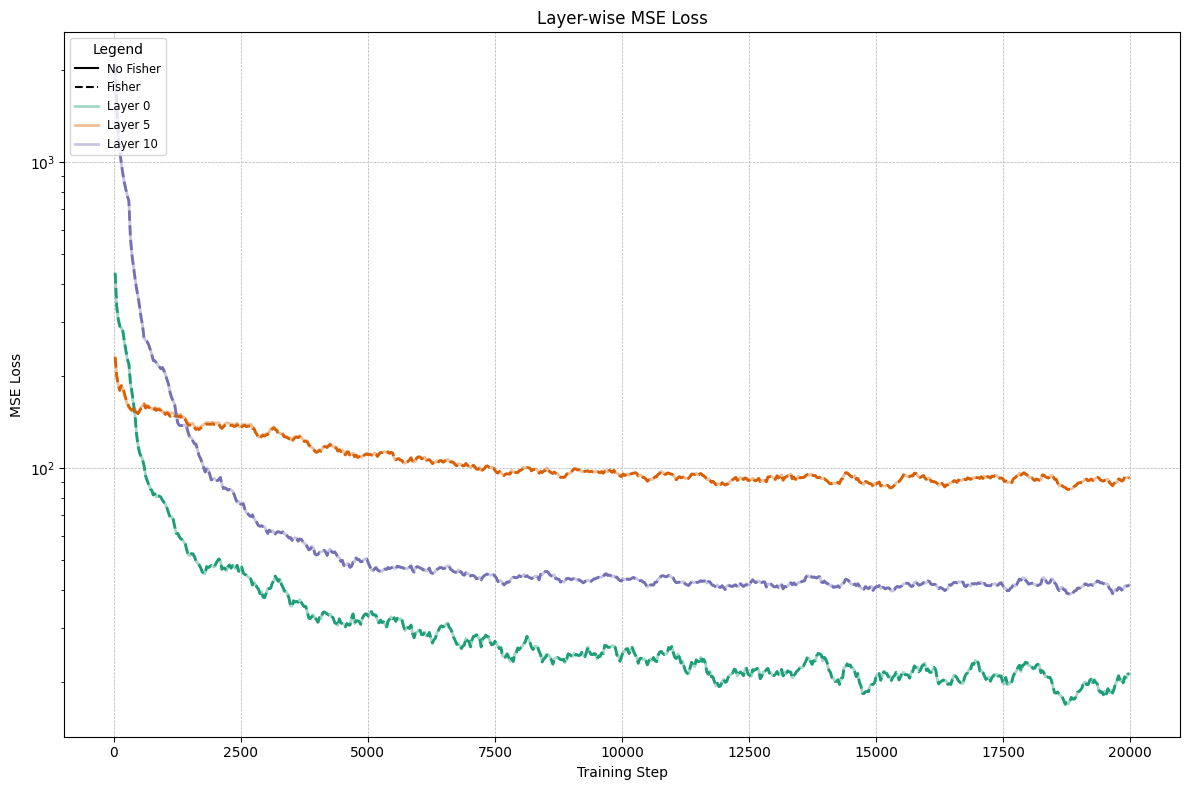

In [9]:
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_standard_mse_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/standard_mse_loss_plot.pdf',
    use_log_scale=True,
    smooth=True
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_jumprelu_mse_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/jumprelu_mse_loss_plot.pdf',
    use_log_scale=True,
    smooth=True
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_gated_mse_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/gated_mse_loss_plot.pdf',
    use_log_scale=True,
    smooth=True
)

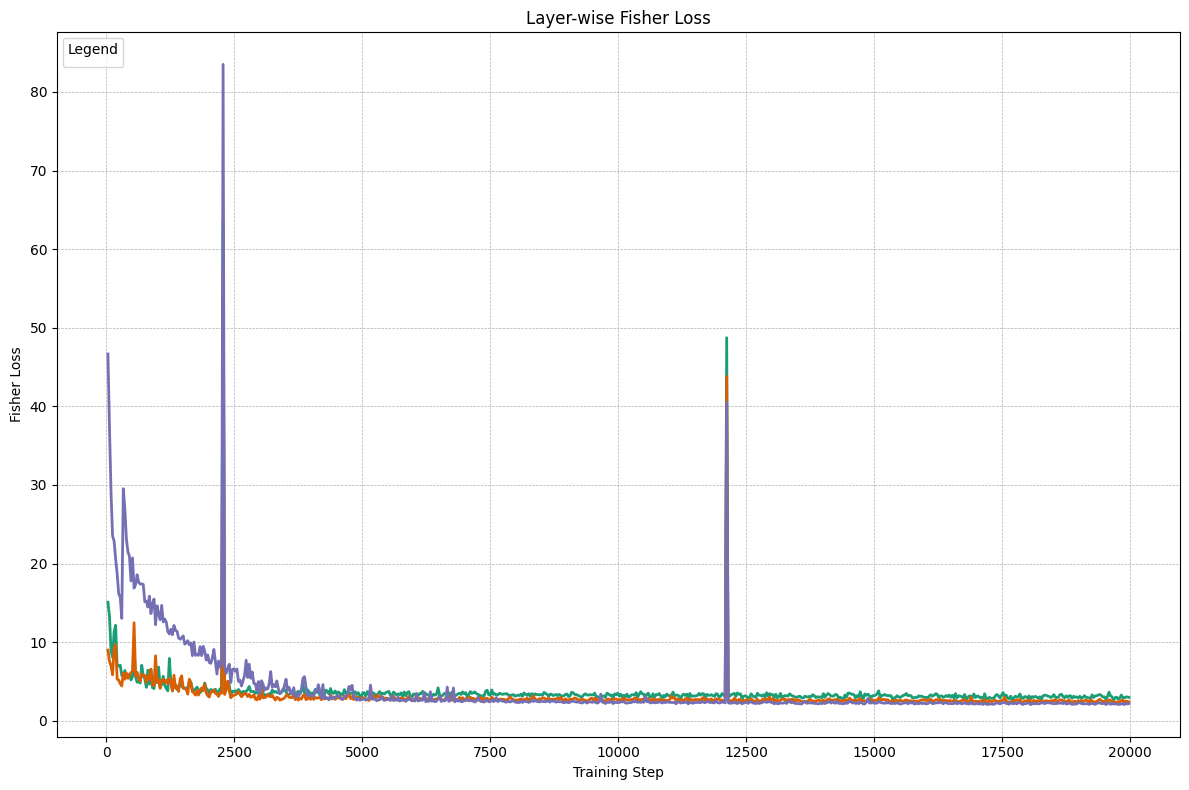

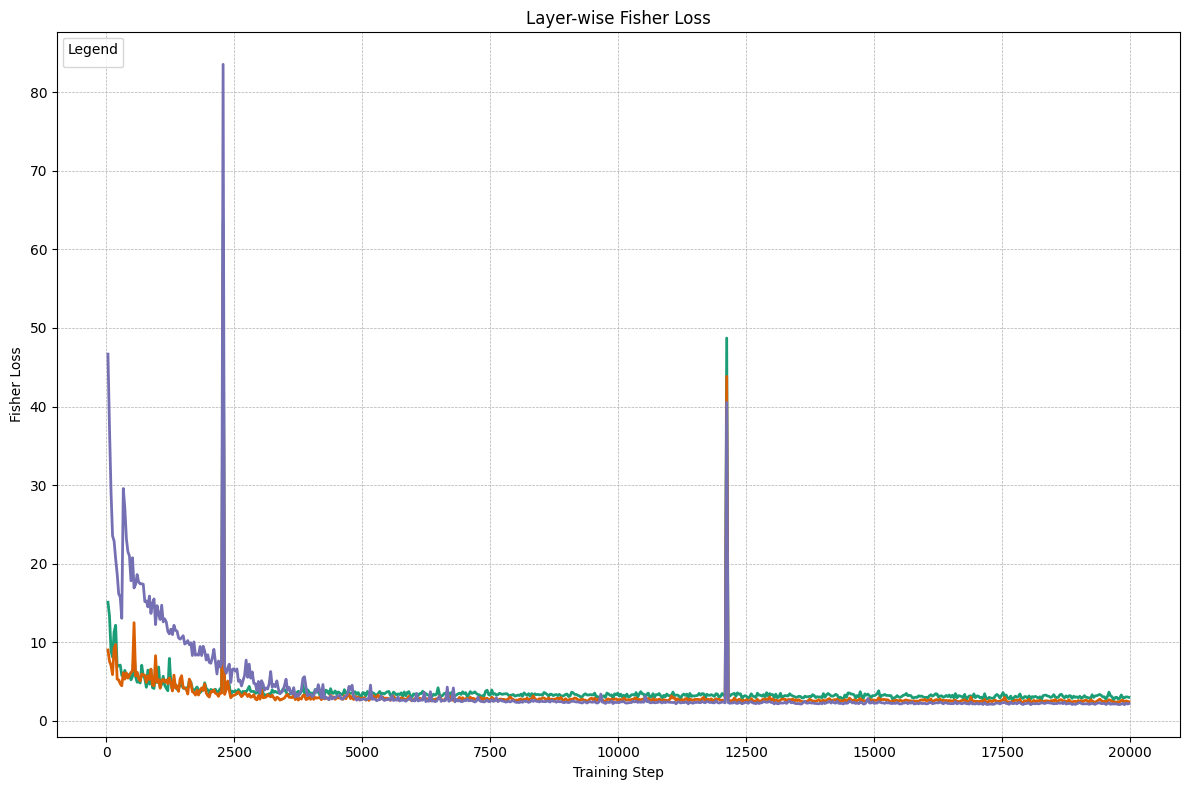

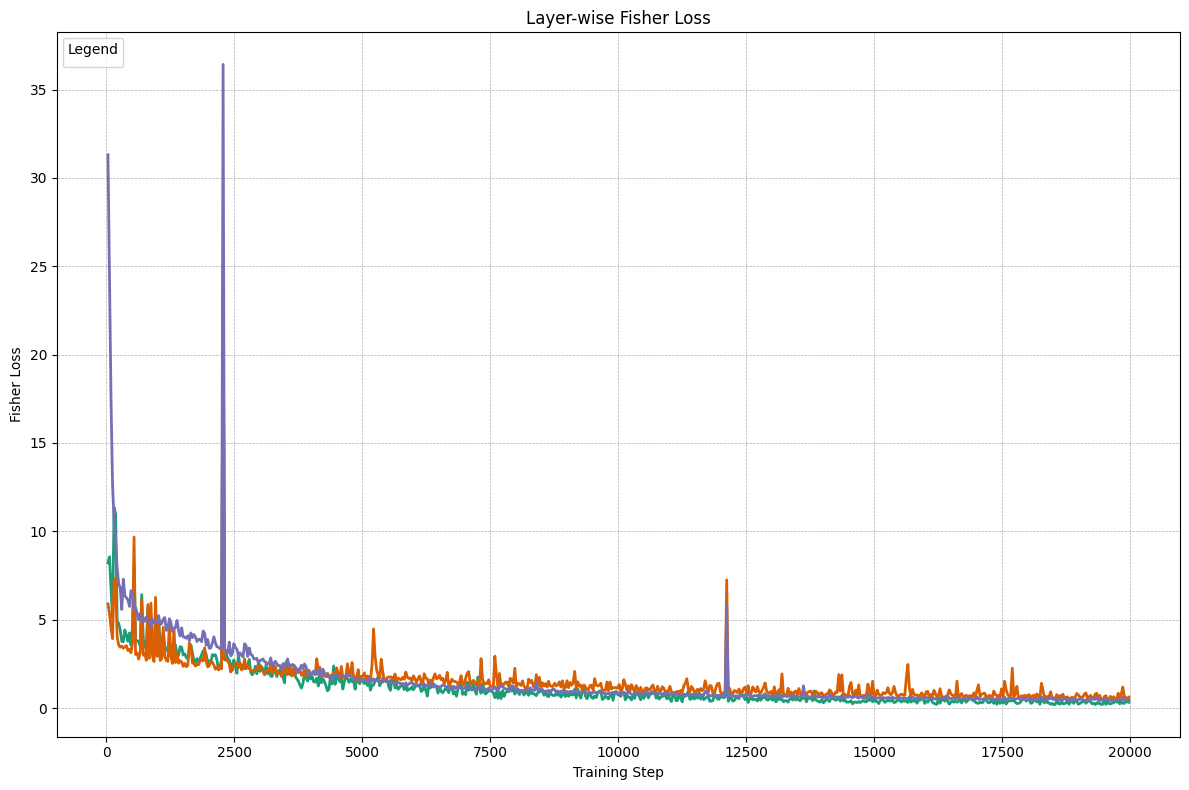

In [10]:
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_standard_fisher_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/fisher_loss_plot.pdf',
    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_jumprelu_fisher_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/jumprelu_fisher_loss_plot.pdf',
    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_mlp_out/Devign_mlp_out_gpt_gated_fisher_loss.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_mlp_out_gpt2',
    output_file='Devign_mlp_out/gated_fisher_loss_plot.pdf',
    include_fisher_legend=False,
    use_log_scale=False,
)

In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Define the root directories for each component
root_dirs = {
    "hook_resid_mid_gpt2": "Devign_residual_mid",
    "hook_mlp_out_gpt2": "Devign_mlp_out"
}

# Define the metrics of interest
metrics = [
    ("sparsity.l0", "l0_sparsity"),
    ("sparsity.l1", "l1_sparsity"),
    ("losses/mse_loss", "mse_loss"),
    ("losses/fisher_reg_term", "fisher_loss"),
    ("shrinkage.l2_ratio", "l2_ratio")
]

# Collect summary information
summary = []

# Iterate through root dirs and corresponding component
for component, root_dir in root_dirs.items():
    for file in os.listdir(root_dir):
        if file.endswith(".csv"):
            full_path = os.path.join(root_dir, file)
            df = pd.read_csv(full_path)
            for layer in [0, 5, 10]:
                for metric_key, metric_name in metrics:
                    col_candidates = [col for col in df.columns if f"layer_{layer}" in col and metric_key in col]
                    for col in col_candidates:
                        print(f"Processing {col} in {file} for layer {layer}")
                        try:
                            last_value = df[col].dropna().iloc[-1]
                            summary.append({
                                "Component": component,
                                "File": file,
                                "Layer": layer,
                                "Metric": metric_name,
                                "Value": last_value,
                                "Fisher": "fisher_true" in col.lower(),
                                "Architecture": "gated" if "gated" in col.lower() else "jumprelu" if "jumprelu" in col.lower() else "standard"
                            })
                        except IndexError:
                            continue

# Create summary DataFrame
summary_df = pd.DataFrame(summary)



Processing layer_5_hook_resid_mid_gpt2_standard_fisher_false_project_Devign - losses/mse_loss in Devign_residual_gpt_layer_5_mse_loss.csv for layer 5
Processing layer_5_hook_resid_mid_gpt2_standard_fisher_false_project_Devign - losses/mse_loss__MIN in Devign_residual_gpt_layer_5_mse_loss.csv for layer 5
Processing layer_5_hook_resid_mid_gpt2_standard_fisher_false_project_Devign - losses/mse_loss__MAX in Devign_residual_gpt_layer_5_mse_loss.csv for layer 5
Processing layer_5_hook_resid_mid_gpt2_topk_fisher_false_project_Devign - losses/mse_loss in Devign_residual_gpt_layer_5_mse_loss.csv for layer 5
Processing layer_5_hook_resid_mid_gpt2_topk_fisher_false_project_Devign - losses/mse_loss__MIN in Devign_residual_gpt_layer_5_mse_loss.csv for layer 5
Processing layer_5_hook_resid_mid_gpt2_topk_fisher_false_project_Devign - losses/mse_loss__MAX in Devign_residual_gpt_layer_5_mse_loss.csv for layer 5
Processing layer_5_hook_resid_mid_gpt2_jumprelu_fisher_false_project_Devign - losses/mse_los

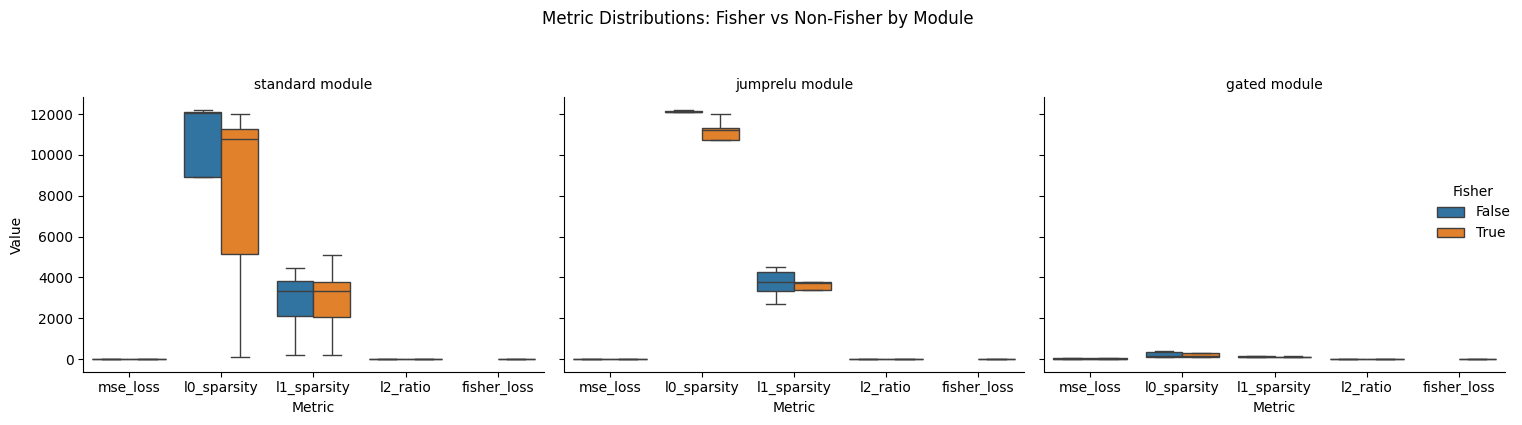

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt


# Plotting visual comparison of Fisher vs Non-Fisher across metrics
g = sns.catplot(
    data=summary_df,
    x="Metric", y="Value", hue="Fisher", col="Architecture",
    kind="box", col_wrap=3, height=4, aspect=1.2,
    showfliers=False
)
g.set_titles("{col_name} module")
g.set_axis_labels("Metric", "Value")
g.fig.suptitle("Metric Distributions: Fisher vs Non-Fisher by Module", y=1.05)
plt.tight_layout()
plt.show()


In [57]:
# Calculate average metric values grouped by Fisher and subtract Non-Fisher from Fisher
avg_metrics = summary_df.groupby(['Architecture', 'Metric', 'Fisher', "Component"])['Value'].mean().reset_index()

# Pivot the data so we have Fisher and Non-Fisher in columns
pivot_df = avg_metrics.pivot(index=['Architecture', 'Metric', "Component"], columns='Fisher', values='Value').reset_index()
pivot_df.columns.name = None  # Remove pandas default name

# Rename columns for clarity
pivot_df.rename(columns={False: 'Non-Fisher', True: 'Fisher'}, inplace=True)

# Add a column for the difference: Fisher - Non-Fisher
pivot_df['Fisher - Non-Fisher'] = pivot_df['Fisher'] - pivot_df['Non-Fisher']
# remove where the metric is "fisher_loss"
pivot_df = pivot_df[pivot_df['Metric'] != 'fisher_loss']

pivot_df['Fisher - Non-Fisher (percentage)'] = (
    pivot_df['Fisher - Non-Fisher'] / pivot_df['Non-Fisher'] * 100
).round(2)
pivot_df

,Architecture,Metric,Component,Non-Fisher,Fisher,Fisher - Non-Fisher,Fisher - Non-Fisher (percentage)
2,gated,l0_sparsity,hook_mlp_out_gpt2,222.094874,199.635213,-22.459661,-10.11
3,gated,l0_sparsity,hook_resid_mid_gpt2,207.220584,176.223882,-30.996702,-14.96
4,gated,l1_sparsity,hook_mlp_out_gpt2,123.979375,121.431257,-2.548119,-2.06
5,gated,l1_sparsity,hook_resid_mid_gpt2,106.574755,103.088056,-3.486699,-3.27
6,gated,l2_ratio,hook_mlp_out_gpt2,1.348515,1.349296,0.000781,0.06
7,gated,l2_ratio,hook_resid_mid_gpt2,3.580490,3.580079,-0.000411,-0.01
8,gated,mse_loss,hook_mlp_out_gpt2,53.861830,53.788914,-0.072917,-0.14
9,gated,mse_loss,hook_resid_mid_gpt2,27.608579,27.713046,0.104467,0.38
12,jumprelu,l0_sparsity,hook_mlp_out_gpt2,12198.583008,11736.963542,-461.619466,-3.78
13,jumprelu,l0_sparsity,hook_resid_mid_gpt2,12017.920247,9608.520345,-2409.399902,-20.05


# Dump

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from matplotlib.lines import Line2D

def plot_layer_metrics(
    file_path: str,
    project_name: str,
    layers: List[int],
    fisher_options: List[bool],
    module_types: List[str],
    title: str,
    ylabel: str,
    component: str,
    metric: str,
    output_file: str = None,
    smooth: bool = False,
    include_fisher_legend: bool = True,
    use_log_scale: bool = True
):
    # Load data
    df = pd.read_csv(file_path)
    x = df['Step']

    # Define styles
    colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']
    line_styles = {True: '--', False: '-'}  # Fisher: dashed, No Fisher: solid
    if not include_fisher_legend:
        line_styles = {True: '-', False: '-'}  # Both Fisher and No Fisher as solid lines   

    # Set up subplots
    fig, axes = plt.subplots(nrows=len(layers), ncols=1, figsize=(10, 3 * len(layers)), sharex=True)
    if len(layers) == 1:
        axes = [axes]  # Ensure iterable

    for i, layer in enumerate(layers):
        ax: plt.Subplot = axes[i]
        plotted_labels = set()

        for j, module in enumerate(module_types):
            for fisher in fisher_options:
                fisher_str = str(fisher).lower()
                col_name = f"layer_{layer}_{component}_{module}_fisher_{fisher_str}_project_{project_name} - {metric}"

                if col_name not in df.columns:
                    print(f"Warning: Missing column '{col_name}'")
                    continue

                y = df[col_name]
                label = module
                plot_label = label if label not in plotted_labels else None
                if plot_label:
                    plotted_labels.add(label)
                
                if smooth:
                    y = y.rolling(window=10, min_periods=1).mean()

                ax.plot(
                    x, y,
                    label=plot_label,
                    color=colors[j % len(colors)],
                    linestyle=line_styles[fisher],
                    linewidth=2,
                    alpha=0.4 if not fisher else 1.0,
                )

        ax.set_ylabel(f"Layer {layer}\n{ylabel}")
        if use_log_scale:
            ax.set_yscale('log')
        ax.grid(True, linestyle='--', linewidth=0.5)
        if i == 0:
            ax.set_title(title)
        if i == len(layers) - 1:
            ax.set_xlabel('Training Step')

        # Add custom line style legend (only once)
        if i == 0:
            module_legend = ax.get_legend_handles_labels()
            if include_fisher_legend:
                # Custom legend for Fisher lines
                custom_lines = [
                    Line2D([0], [0], color='black', linestyle='-', label='No Fisher'),
                    Line2D([0], [0], color='black', linestyle='--', label='Fisher')
                ]
            else:
                custom_lines = []
            ax.legend(
                handles=custom_lines + module_legend[0],
                loc='upper left',
                fontsize='small',
                title='Fisher Options'
            )

    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()



## Devign

In [ ]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l0_sparsity.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l0_sparsity.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer5_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l0_sparsity.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer10_l0_sparsity_plot.pdf',
    use_log_scale=False
)

In [ ]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l1_sparsity.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l1_sparsity.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer5_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l1_sparsity.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer10_l1_sparsity_plot.pdf'
)

In [ ]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l2_ratio.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l2_ratio_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l2_ratio.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer5_l2_ratio_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l2_ratio.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer10_l2_ratio_plot.pdf'
)

In [ ]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_mse_loss.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_mse_loss_plot.pdf',
    # smooth=True,
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_mse_loss.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer5_mse_loss_plot.pdf',
    # smooth=True,
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_mse_loss.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer10_mse_loss_plot.pdf',
    # smooth=True,
    # use_log_scale=False
)

In [ ]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_fisher_loss.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_fisher_loss_plot.pdf',
    # smooth=True,
    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_fisher_loss.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer5_fisher_loss_plot.pdf',
    # smooth=True,
    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_fisher_loss.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer10_fisher_loss_plot.pdf',
    # smooth=True,
    include_fisher_legend=False,
    use_log_scale=False,
)

## Tiny Stories

In [ ]:
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_0_l0_sparsity.csv',
    layers=[0],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer0_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_5_l0_sparsity.csv',
    layers=[5],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer_5_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_10_l0_sparsity.csv',
    layers=[10],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer_10_l0_sparsity_plot.pdf'
)

In [ ]:
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_0_l1_sparsity.csv',
    layers=[0],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer0_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_5_l1_sparsity.csv',
    layers=[5],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell1$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer_5_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_10_l1_sparsity.csv',
    layers=[10],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer_10_l1_sparsity_plot.pdf'
)